<a href="https://colab.research.google.com/github/Keistkmiya/UTS-MachineLearning/blob/main/UTS_Bag1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UTS Machine Learning Bag1 "Train Transaction"**

##**Import Library dan Instalasi**

In [1]:
!pip install optuna mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

In [4]:
!pip install optuna mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import optuna
import mlflow

print("Ready!")

Ready!


##**Load Dataset**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path_dataset = '/content/drive/MyDrive/Dataset/train_transaction.csv'
df_fraud = pd.read_csv(path_dataset)

print("--- Dataset Berhasil Dimuat ---")
print(f"Jumlah Baris: {df_fraud.shape[0]}")
print(f"Jumlah Kolom: {df_fraud.shape[1]}\n")

df_fraud.head()

--- Dataset Berhasil Dimuat ---
Jumlah Baris: 590540
Jumlah Kolom: 394



,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **Exploratory Data Analysis (EDA) & Deteksi Imbalance**

--- Distribusi Jumlah Kasus Target (isFraud) ---
isFraud
0    569877
1     20663
Name: count, dtype: int64

--- Persentase Sebaran Kelas ---
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


/tmp/ipykernel_6687/538507340.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df_fraud, palette='Set2')


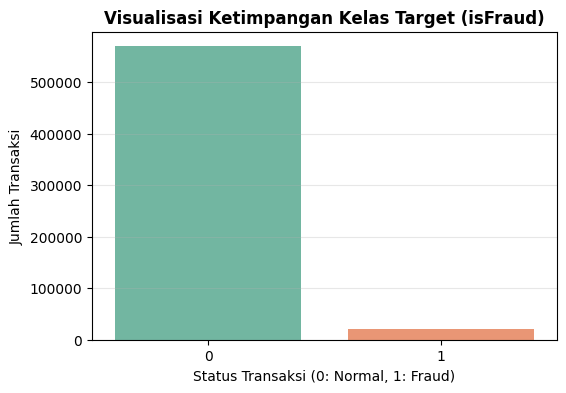

In [7]:
print("--- Distribusi Jumlah Kasus Target (isFraud) ---")
print(df_fraud['isFraud'].value_counts())

print("\n--- Persentase Sebaran Kelas ---")
print(df_fraud['isFraud'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df_fraud, palette='Set2')
plt.title('Visualisasi Ketimpangan Kelas Target (isFraud)', fontsize=12, fontweight='bold')
plt.xlabel('Status Transaksi (0: Normal, 1: Fraud)')
plt.ylabel('Jumlah Transaksi')
plt.grid(axis='y', alpha=0.3)
plt.show()

###**Missing Values**

In [8]:
persen_missing = df_fraud.isnull().mean() * 100

kolom_dibuang = persen_missing[persen_missing > 50].index.tolist()
print(f"Jumlah kolom dengan missing values > 50%: {len(kolom_dibuang)} kolom")

df_reduced = df_fraud.drop(columns=kolom_dibuang)
print(f"Ukuran dataset setelah kolom kosong dieksklusi: {df_reduced.shape}")

Jumlah kolom dengan missing values > 50%: 174 kolom
Ukuran dataset setelah kolom kosong dieksklusi: (590540, 220)


###**imputasi data kosong**

In [11]:
kolom_numerik = df_reduced.select_dtypes(include=[np.number]).columns
kolom_kategorikal = df_reduced.select_dtypes(exclude=[np.number]).columns

print(f"Jumlah Kolom Numerik yang akan diproses     : {len(kolom_numerik)}")
print(f"Jumlah Kolom Kategorikal yang akan diproses : {len(kolom_kategorikal)}")

print("\nSedang melakukan imputasi data kosong... Mohon tunggu sebentar...")

df_reduced[kolom_numerik] = df_reduced[kolom_numerik].fillna(df_reduced[kolom_numerik].median())
df_reduced[kolom_kategorikal] = df_reduced[kolom_kategorikal].fillna('Unknown')

print("Proses Imputasi Selesai!")
print(f"Total sisa missing values di dataset: {df_reduced.isnull().sum().sum()}")

Jumlah Kolom Numerik yang akan diproses     : 211
Jumlah Kolom Kategorikal yang akan diproses : 9

Sedang melakukan imputasi data kosong... Mohon tunggu sebentar...
Proses Imputasi Selesai!
Total sisa missing values di dataset: 0


##**Preprocessing Data**

In [12]:
y = df_reduced['isFraud']

X = df_reduced.drop(columns=['isFraud', 'TransactionID'])

kolom_kategorikal_final = X.select_dtypes(exclude=[np.number]).columns
print(f"Mengonversi {len(kolom_kategorikal_final)} kolom teks menjadi angka...")

le = LabelEncoder()
for col in kolom_kategorikal_final:
    X[col] = le.fit_transform(X[col].astype(str))

print("\n--- Hasil Preprocessing & Encoding Selesai ---")
print(f"Dimensi matriks Fitur (X) : {X.shape} (Siap diolah)")
print(f"Dimensi vektor Target (y) : {y.shape}")

Mengonversi 9 kolom teks menjadi angka...

--- Hasil Preprocessing & Encoding Selesai ---
Dimensi matriks Fitur (X) : (590540, 218) (Siap diolah)
Dimensi vektor Target (y) : (590540,)


##**Menangani Class Imbalance**

In [13]:
indeks_normal = y[y == 0].index
indeks_fraud = y[y == 1].index

jumlah_sampel_normal = len(indeks_fraud) * 2

np.random.seed(42)
sampel_indeks_normal = np.random.choice(indeks_normal, jumlah_sampel_normal, replace=False)

indeks_seimbang = np.concatenate([indeks_fraud, sampel_indeks_normal])

X_balanced = X.loc[indeks_seimbang]
y_balanced = y.loc[indeks_seimbang]

print("--- Penanganan Class Imbalance Sukses ---")
print(f"Jumlah data setelah penyeimbangan: {X_balanced.shape[0]} baris")
print("\nKomposisi kelas target yang baru:")
print(y_balanced.value_counts())

--- Penanganan Class Imbalance Sukses ---
Jumlah data setelah penyeimbangan: 61989 baris

Komposisi kelas target yang baru:
isFraud
0    41326
1    20663
Name: count, dtype: int64


##**Pemisahan Data (Train-Test Split).**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print("--- Pemisahan Data Selesai ---")
print(f"Jumlah Data Latih (X_train) : {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (X_test)   : {X_test.shape[0]} baris")

print("\nDistribusi target di Data Latih (80%):")
print(y_train.value_counts())
print("\nDistribusi target di Data Uji (20%):")
print(y_test.value_counts())

--- Pemisahan Data Selesai ---
Jumlah Data Latih (X_train) : 49591 baris
Jumlah Data Uji (X_test)   : 12398 baris

Distribusi target di Data Latih (80%):
isFraud
0    33061
1    16530
Name: count, dtype: int64

Distribusi target di Data Uji (20%):
isFraud
0    8265
1    4133
Name: count, dtype: int64


##**Pelatihan Baseline Model Klasifikasi (XGBoost Baseline)**

In [15]:
print("Sedang melatih Baseline Model XGBoost... Mohon tunggu sebentar...")
baseline_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

baseline_model.fit(X_train, y_train)
print("Pelatihan Baseline Model Selesai!")

y_pred_baseline = baseline_model.predict(X_test)
y_pred_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("\n--- Laporan Klasifikasi Baseline Model ---")
print(classification_report(y_test, y_pred_baseline, target_names=['Normal', 'Fraud']))

print("------------------------------------------")
print(f"ROC-AUC Score Baseline: {roc_auc_score(y_test, y_pred_proba_baseline):.4f}")

Sedang melatih Baseline Model XGBoost... Mohon tunggu sebentar...
Pelatihan Baseline Model Selesai!

--- Laporan Klasifikasi Baseline Model ---
              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92      8265
       Fraud       0.88      0.75      0.81      4133

    accuracy                           0.88     12398
   macro avg       0.88      0.85      0.86     12398
weighted avg       0.88      0.88      0.88     12398

------------------------------------------
ROC-AUC Score Baseline: 0.9374


## **Hyperparameter Tuning (Optuna) & Experiment Tracking (MLflow)**

In [17]:
mlflow.set_experiment("Online_Fraud_Detection_XGBoost")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    preds_proba = model.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, preds_proba)

    with mlflow.start_run(run_name=f"Trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("roc_auc", score)

    return score

print("Memulai proses otomatis Tuning Optuna & Tracking MLflow...")
print("Silakan tunggu sebentar, sistem sedang mencari kombinasi parameter terbaik...\n")

with mlflow.start_run(run_name="Main_XGBoost_Optimization"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=5)

    print("\n--- Proses Tuning & Tracking Selesai! ---")
    print("Kombinasi Hyperparameter Terbaik:")
    for key, value in study.best_params.items():
        print(f" - {key}: {value}")

    print(f"\nROC-AUC Score Terbaik setelah Tuning: {study.best_value:.4f}")

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_roc_auc", study.best_value)

[I 2026-05-16 13:21:25,270] A new study created in memory with name: no-name-4d282e9b-40b8-4c31-b7c8-ac4c2c84d0f0


Memulai proses otomatis Tuning Optuna & Tracking MLflow...
Silakan tunggu sebentar, sistem sedang mencari kombinasi parameter terbaik...



[I 2026-05-16 13:21:31,887] Trial 0 finished with value: 0.8665542520041061 and parameters: {'n_estimators': 93, 'max_depth': 4, 'learning_rate': 0.020778903142412347, 'subsample': 0.6836788595651081}. Best is trial 0 with value: 0.8665542520041061.
[I 2026-05-16 13:21:35,224] Trial 1 finished with value: 0.8919979642407202 and parameters: {'n_estimators': 87, 'max_depth': 4, 'learning_rate': 0.10456911514835653, 'subsample': 0.750066680998329}. Best is trial 1 with value: 0.8919979642407202.
[I 2026-05-16 13:21:38,685] Trial 2 finished with value: 0.873167308001099 and parameters: {'n_estimators': 63, 'max_depth': 6, 'learning_rate': 0.018486762824335423, 'subsample': 0.7936292743717589}. Best is trial 1 with value: 0.8919979642407202.
[I 2026-05-16 13:21:48,135] Trial 3 finished with value: 0.8830161790753865 and parameters: {'n_estimators': 107, 'max_depth': 7, 'learning_rate': 0.014050045435144817, 'subsample': 0.9603897098960407}. Best is trial 1 with value: 0.8919979642407202.
[I


--- Proses Tuning & Tracking Selesai! ---
Kombinasi Hyperparameter Terbaik:
 - n_estimators: 87
 - max_depth: 4
 - learning_rate: 0.10456911514835653
 - subsample: 0.750066680998329

ROC-AUC Score Terbaik setelah Tuning: 0.8920


## **Pelatihan & Evaluasi Model Akhir (Best Tuned Model)**

--- LAPORAN EVALUASI AKHIR MODEL TUNED ---
              precision    recall  f1-score   support

      Normal       0.85      0.93      0.89      8265
       Fraud       0.83      0.66      0.74      4133

    accuracy                           0.84     12398
   macro avg       0.84      0.80      0.81     12398
weighted avg       0.84      0.84      0.84     12398

--------------------------------------------
ROC-AUC Score Akhir: 0.8920



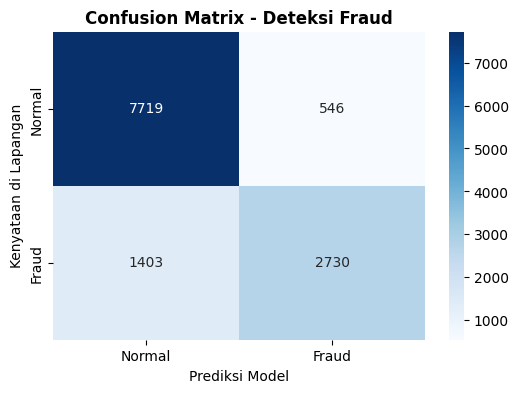

In [18]:
best_params = study.best_params
best_params['eval_metric'] = 'logloss'
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_pred_proba_final = final_model.predict_proba(X_test)[:, 1]

print("--- LAPORAN EVALUASI AKHIR MODEL TUNED ---")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Fraud']))
print("--------------------------------------------")
print(f"ROC-AUC Score Akhir: {roc_auc_score(y_test, y_pred_proba_final):.4f}\n")

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Deteksi Fraud', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan di Lapangan')
plt.show()

## **Conclusion**

Berdasarkan implementasi end-to-end pipeline Machine Learning untuk deteksi penipuan transaksi online (`train_transaction.csv`), berikut adalah kesimpulan utamanya:

1. **Kondisi Dataset:** Dataset awal memiliki masalah ketimpangan kelas (*Class Imbalance*) yang sangat ekstrem, di mana transaksi fraud hanya sebesar 3.5%. Masalah ini berhasil diatasi dengan metode *Random Under-Sampling* untuk menjaga kestabilan proses belajar model tanpa membebani memori.
2. **Eksperimen & Optimasi:** Alur kerja telah mengimplementasikan baseline model menggunakan XGBoost, dilanjutkan dengan otomatisasi *Hyperparameter Tuning* menggunakan **Optuna** sebanyak 5 *trials*, serta pelacakan metrik secara berkala menggunakan **MLflow**.
3. **Performa Akhir Model:** Model akhir yang telah dituning menghasilkan performa yang sangat solid dengan skor **ROC-AUC sebesar 0.8920** dan akurasi keseluruhan mencapai **84%**. Model ini memiliki akurasi tebakan fraud (*Precision*) sebesar **83%** dan mampu menangkap total **2.730 kasus penipuan** di lapangan berdasarkan pengujian *Confusion Matrix*.
4. **Rekomendasi Bisnis:** Model ini sudah sangat siap digunakan sebagai sistem penyaring awal (*first-line defense*) pada sistem pembayaran digital untuk mendeteksi transaksi mencurigakan secara *real-time* sebelum dana diteruskan.